计算一个给定轨迹的return

In [2]:
import numpy as np

# 设置随机数种子，使该实验可复现
np.random.seed(0)

# 定义状态转移矩阵
p = [
    [0.9, 0.1, 0.0, 0.0, 0.0, 0.0],
    [0.5, 0.0, 0.5, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.6, 0.0, 0.4],
    [0.0, 0.0, 0.0, 0.0, 0.3, 0.7],
    [0.0, 0.2, 0.3, 0.5, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
]
P = np.array(p)

# 定义奖励函数(映射每个状态的奖励)
rewards = [-1, -2, -2, 10, 1, 0]

# 定义折扣因子
gamma = 0.5

def compute_return(start_index, chain, gamma):
    """
        计算一条给定轨迹的return
        start_index：起始状态索引
        chain：轨迹
        gamma：折扣因子
    """
    G = 0
    for i in reversed(range(start_index, len(chain))):
        G = gamma * G + rewards[chain[i] - 1]
    return G
    
# 起始状态
start_index = 0
# 轨迹
chain = [1, 2, 3, 6]

print("根据本序列计算得到回报为：%s。" % compute_return(start_index,chain,gamma))

根据本序列计算得到回报为：-2.5。


求解价值函数的解析解方法，并据此计算该马尔可夫奖励过程中所有状态的价值。这里会应用到矩阵的逆，后面我们一般不求解析解，而是使用迭代法求解，在这里计算完后，也可以使用贝尔曼公式来验证一下    - $$V_\pi(s)=R_\pi(s)+γ*\sum_{s'}p_\pi(s'|s)v_\pi(s')$$解析解：    $$V=(I-γ*P)^{-1}R$$

In [3]:
def compute_state_value(P, rewards, gamma, states_num):
    """
        计算state value
        P：状态转移矩阵
        rewards：奖励列表（标量）
        gamma：折扣因子
        states_num：状态总数
    """
    # 将rewards写成列向量形式，因为其原本为标量，无法运行矩阵乘法
    rewards = np.array(rewards).reshape((-1, 1))  
    # 根据解析解的公式来解算state value 
    value = np.dot(np.linalg.inv(np.eye(states_num, states_num) - gamma * P),
                   rewards)
    return value

print("MRP中每个状态价值分别为\n", compute_state_value(P,rewards,gamma,6))

MRP中每个状态价值分别为
 [[-2.01950168]
 [-2.21451846]
 [ 1.16142785]
 [10.53809283]
 [ 3.58728554]
 [ 0.        ]]


实现马尔科夫决策过程，我们定义两个策略，一个是随机的策略，还有一个是设定好的策略（并不是说只有单独一个动作的选择）
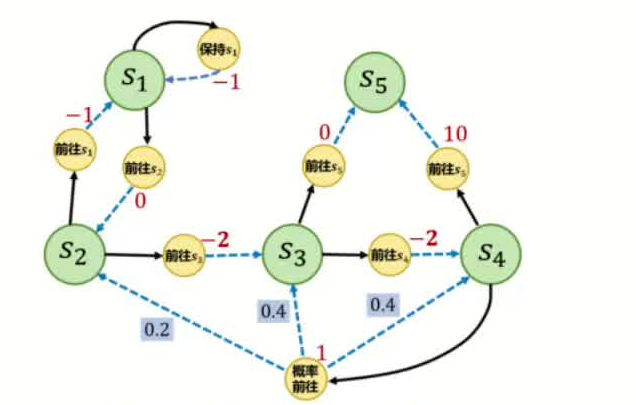

In [4]:
# 状态集合
S = ["s1", "s2", "s3", "s4", "s5"]  
# 动作集合
A = ["保持s1", "前往s1", "前往s2", "前往s3", "前往s4", "前往s5", "概率前往"]  
# 状态转移函数；P(s'|s,a)
P = {
    # s   a   s'     P
    "s1-保持s1-s1": 1.0,
    "s1-前往s2-s2": 1.0,
    "s2-前往s1-s1": 1.0,
    "s2-前往s3-s3": 1.0,
    "s3-前往s4-s4": 1.0,
    "s3-前往s5-s5": 1.0,
    "s4-前往s5-s5": 1.0,
    "s4-概率前往-s2": 0.2,
    "s4-概率前往-s3": 0.4,
    "s4-概率前往-s4": 0.4,
}
# 奖励函数：R(s,a)
R = {
    # s    a     r 
    "s1-保持s1": -1,
    "s1-前往s2": 0,
    "s2-前往s1": -1,
    "s2-前往s3": -2,
    "s3-前往s4": -2,
    "s3-前往s5": 0,
    "s4-前往s5": 10,
    "s4-概率前往": 1,
}

MDP = (S,A,P,R,gamma)

# 策略1,随机策略
Pi_1 = {
    # s   a    Pi(a|s)
    "s1-保持s1": 0.5,
    "s1-前往s2": 0.5,
    "s2-前往s1": 0.5,
    "s2-前往s3": 0.5,
    "s3-前往s4": 0.5,
    "s3-前往s5": 0.5,
    "s4-前往s5": 0.5,
    "s4-概率前往": 0.5,
}
# 策略2
Pi_2 = {
    # s   a    Pi(a|s)
    "s1-保持s1": 0.6,
    "s1-前往s2": 0.4,
    "s2-前往s1": 0.3,
    "s2-前往s3": 0.7,
    "s3-前往s4": 0.5,
    "s3-前往s5": 0.5,
    "s4-前往s5": 0.1,
    "s4-概率前往": 0.9,
}

def join(str1, str2):
    """
        把输入的两个字符串通过“-”连接,便于使用上述定义的P、R变量
    """
    return str1 + '-' + str2

对于某一个状态，我们根据策略所有动作的概率进行加权，得到的奖励和就可以认为是一个 MRP 在该状态下的奖励，即：
$$r'(s) = \sum_a \pi(a|s)r(s,a)$$同理，我们计算采取动作的概率与使 s 转移到 s' 的概率的乘积，再将这些乘积相加，其和就是一个 MRP 的状态从 s 转移至 s' 的概率：
$$P'(s'|s) = \sum_a \pi(a|s)P(s'|s,a)$$

转化前的 MDP 的状态价值函数和转化后的 MRP 的价值函数是一样的。于是我们可以用 MRP 中计算价值函数的解析解来计算这个 MDP 中该策略的状态价值函数。

In [5]:
# 转化后的MRP的状态转移矩阵(这里是随机策略的)
P_from_mdp_to_mrp = [
    [0.5, 0.5, 0.0, 0.0, 0.0],
    [0.5, 0.0, 0.5, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.5, 0.5],
    [0.0, 0.1, 0.2, 0.2, 0.5],
    [0.0, 0.0, 0.0, 0.0, 1.0],
]

# 变成矩阵，方便直接运用矩阵计算
P_from_mdp_to_mrp = np.array(P_from_mdp_to_mrp)     # 状态转移矩阵
R_from_mdp_to_mrp = [-0.5, -1.5, -1.0, 5.5, 0]      # 奖励函数（在每个状态下的奖励）

# 计算状态价值
print("随机策略的MDP中每个状态价值分别为\n", compute_state_value(P_from_mdp_to_mrp,R_from_mdp_to_mrp,gamma,5))

随机策略的MDP中每个状态价值分别为
 [[-1.22555411]
 [-1.67666232]
 [ 0.51890482]
 [ 6.0756193 ]
 [ 0.        ]]


接着来计算一下动作价值$$Q_\pi(s,a)=r(s,a)+γ*\sum_{s'}p(s'|s,a)*V_\pi(s')$$，这里手动计算即可

蒙特卡洛方法

我们先来实现一个采样函数，并且随机采几次样，采样函数需要遵守状态转移矩阵和相应的策略

In [6]:
def sample(MDP, Pi, timestep_max, number):
    """
        依照一种策略来进行采样（获取一条轨迹）
        MDP：马尔科夫决策链
        Pi：策略
        timestep_max：最长时间步
        number：总共采样序列数(生成多少个样本)
    """
    S, A, P, R, gamma = MDP
    # 存储采样得到的轨迹
    episodes = []

    for _ in range(number):
        # 存储当前采样得到的轨迹
        episode = []
        # 当前采样的已执行步长
        timestep = 0
        # 随机选择一个除s5以外的状态s作为起点
        s = S[np.random.randint(4)]  

        # 当前状态为终止状态或者时间步太长时,一次采样结束
        while s != "s5" and timestep <= timestep_max:
            timestep += 1
            # 生成一个随机数和一个临时变量，来根据策略选择动作
            rand, temp = np.random.rand(), 0
            # 在状态s下根据策略选择动作
            for a_opt in A:
                # 将状态s和动作a_opt连接成字符串，来获取Pi(s,a_opt)的值
                temp += Pi.get(join(s, a_opt), 0)
                if temp > rand:
                    a = a_opt
                    r = R.get(join(s, a), 0)  
                    break

            # 这里的原理和上面一样
            rand, temp = np.random.rand(), 0
            # 根据状态转移概率得到下一个状态s_next
            for s_opt in S:
                temp += P.get(join(join(s, a), s_opt), 0)
                if temp > rand:
                    s_next = s_opt
                    break
            
            # 单次采样序列
            episode.append((s, a, r, s_next))  # 把（s,a,r,s_next）元组放入序列中

            # 更新状态为下一个状态
            s = s_next  

        # 将当前采样得到的轨迹放入总的轨迹列表中
        episodes.append(episode)

    return episodes

# 采样5次,每个序列最长不超过20步
episodes = sample(MDP, Pi_1, 20, 5)

print('第一条序列\n', episodes[0])
print('第二条序列\n', episodes[1])
print('第五条序列\n', episodes[4])

第一条序列
 [('s1', '前往s2', 0, 's2'), ('s2', '前往s3', -2, 's3'), ('s3', '前往s5', 0, 's5')]
第二条序列
 [('s4', '概率前往', 1, 's4'), ('s4', '前往s5', 10, 's5')]
第五条序列
 [('s2', '前往s3', -2, 's3'), ('s3', '前往s4', -2, 's4'), ('s4', '前往s5', 10, 's5')]


上面我们通过随机采样，让agent在环境里跑了很多样本，收集了一大堆经验数据（一条条的序列 episodes），现在我们来评估每一个状态到底“有多好”；即 state value ，虽然我们有这个模型，但我们这里使用 MC 来进行求这个 state value 即求平均

In [7]:
def MC(episodes, V, N, gamma):
    """
        通过蒙特卡洛方法来评估状态价值
        episodes：采样得到的轨迹列表
        V：状态价值列表
        N：最大的时间步长
        gamma：折扣因子
    """
    # 遍历每一条轨迹
    for episode in episodes:
        # 初始化当前轨迹的回报
        G = 0            
        #一个序列从后往前计算（第一个值为最后一个时间步的回报，第二个值为终点，第三个值为步长）
        # 因为range() 函数的规则是左闭右开，也就是说它包含起点，但绝对不会包含终点的值，所以这里的终点是-1，起点是len(episode)-1
        # 步长为-1，表示从后往前遍历
        for i in range(len(episode) - 1, -1, -1):  
            (s, a, r, s_next) = episode[i]
            # 计算回报
            G = r + gamma * G
            # 统计状态s被访问的次数
            N[s] = N[s] + 1
            # 根据增量式平均的公式来更新状态s的价值
            V[s] = V[s] + (G - V[s]) / N[s]
    
timestep_max = 20

episodes = sample(MDP, Pi_1, timestep_max, 1000)

# 初始化状态价值和访问次数 
V = {"s1": 0, "s2": 0, "s3": 0, "s4": 0, "s5": 0}
N = {"s1": 0, "s2": 0, "s3": 0, "s4": 0, "s5": 0}

MC(episodes, V, N, gamma)
print("使用蒙特卡洛方法计算MDP的状态价值为\n", V)

使用蒙特卡洛方法计算MDP的状态价值为
 {'s1': -1.228923788722258, 's2': -1.6955696284402704, 's3': 0.4823809701532294, 's4': 5.967514743019431, 's5': 0}


接下来我们编写代码来近似估计占用度量。这里我们采用近似估计，即设置一个较大的采样轨迹长度的最大值，然后采样很多次，用状态动作对出现的频率估计实际概率。（关于占用度量等的知识看我飞书）

In [11]:
def occupancy(episodes, s, a, timestep_max, gamma):
    """
        计算指定状态动作对(s,a)的占用度
        episodes：采样得到的轨迹列表
        s：状态
        a：动作
        timestep_max：最大时间步数
        gamma：折扣因子
    """
    # 初始占用度量为0
    rho = 0
    
    # 在所有的轨迹中，第t个时间步总共被访问了多少次
    total_times = np.zeros(timestep_max)  
    # 在第t个时间步，刚好处于状态s且采取了动作a的次数
    occur_times = np.zeros(timestep_max)  

    # 用于确认当前采样中（s,a）的出现情况
    for episode in episodes:
        for i in range(len(episode)):
            # 获取当前时间步的状态、动作、奖励和下一个状态
            (s_opt, a_opt, r, s_next) = episode[i]
            # 时间步加1
            total_times[i] += 1
            # 如果在第i个时间步，状态s_opt和动作a_opt分别等于输入的状态s和动作a，那么就把occur_times[i]加1
            if s == s_opt and a == a_opt:
                # 记录（s，a）出现的次数加1
                occur_times[i] += 1

    # 从后往前遍历每个时间步
    for i in reversed(range(timestep_max)):
        # 如果在第i个时间步总共被访问了total_times[i]次，那么就把占用度量rho加上gamma的i次幂乘以occur_times[i]除以total_times[i]
        if total_times[i]:
            # 占用度量rho加上gamma的i次幂乘以occur_times[i]除以total_times[i]
            rho += gamma**i * occur_times[i] / total_times[i]           

    # 返回占用度量
    return (1 - gamma) * rho


timestep_max = 1000
episodes_1 = sample(MDP, Pi_1, timestep_max, 1000)
episodes_2 = sample(MDP, Pi_2, timestep_max, 1000)

rho_1 = occupancy(episodes_1, "s4", "概率前往", timestep_max, gamma)
rho_2 = occupancy(episodes_2, "s4", "概率前往", timestep_max, gamma)
print(rho_1, rho_2)

0.10395776401475135 0.24711299717563512


通过以上结果可以发现，不同策略对于同一个状态动作对的占用度量是不一样的